In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# LinearRegressionModel (scratch __version__)
# Formula: y = a + bx
# a: bias (intercepter)
# b: weight (slope)
# x: imaginary number

weight = 0.7
bias = 0.3

# PyTorch RandomSeed
torch.manual_seed(42)

X = torch.arange(0, 10, 0.1).unsqueeze(dim=1)
y = bias + weight * X

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [9]:
# LinearRegressionModel (PyTorch __version__)

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = torch.nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.bias + self.weights * x

In [10]:
model = LinearRegressionModel()

In [11]:
with torch.inference_mode():
    y_pred = model(X_train)

In [12]:
X_train.shape, y_train.shape

(torch.Size([80, 1]), torch.Size([80, 1]))

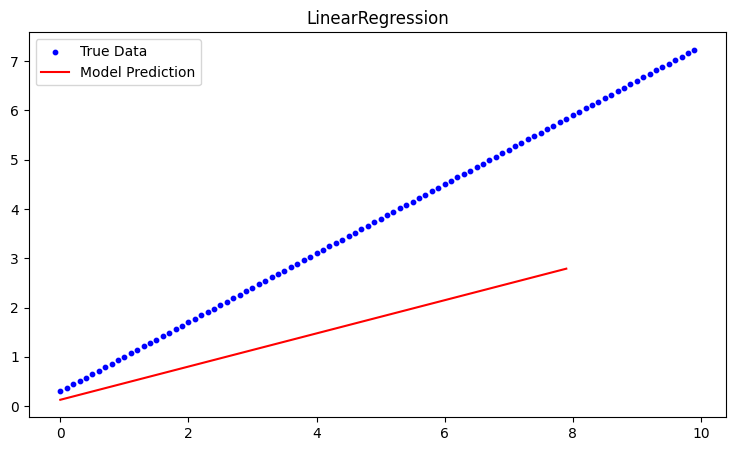

In [13]:
plt.figure(figsize=(9, 5))
plt.title("LinearRegression")
plt.scatter(X, y, label="True Data", c="blue", s=10)
plt.plot(X_train, y_pred, label="Model Prediction", c="red")
plt.legend()
plt.show()

In [14]:
## Loss Function & Optimizer

# L1Loss func
loss_func = torch.nn.L1Loss()

# Optimizer

optimizer = torch.optim.SGD(params = model.parameters(),
                           lr=0.001)

Epoch: 000 | Loss: 1.6062637567520142 | Test Loss: 3.3864593505859375
Epoch: 010 | Loss: 1.44023859500885 | Test Loss: 3.0229344367980957
Epoch: 020 | Loss: 1.2742136716842651 | Test Loss: 2.659409284591675
Epoch: 030 | Loss: 1.1081886291503906 | Test Loss: 2.295884370803833
Epoch: 040 | Loss: 0.9421636462211609 | Test Loss: 1.9323596954345703
Epoch: 050 | Loss: 0.7761386632919312 | Test Loss: 1.5688343048095703
Epoch: 060 | Loss: 0.6101135015487671 | Test Loss: 1.2053096294403076
Epoch: 070 | Loss: 0.44408854842185974 | Test Loss: 0.8417843580245972
Epoch: 080 | Loss: 0.27806356549263 | Test Loss: 0.4782591760158539
Epoch: 090 | Loss: 0.1120385155081749 | Test Loss: 0.11473450809717178


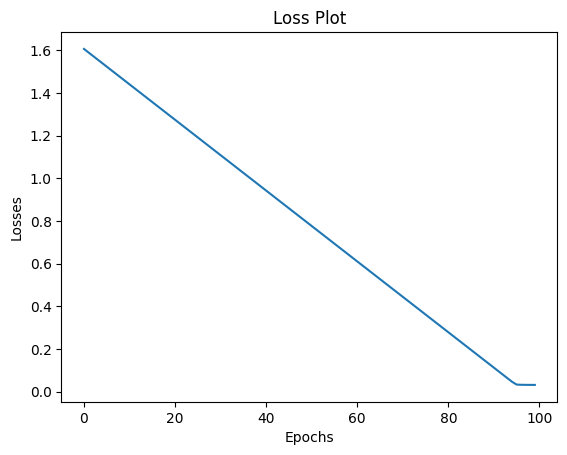

In [15]:
torch.manual_seed(42)

epochs = 100
epoch_loop = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_func(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    # Testing Model
    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test)

        test_loss = loss_func(y_test_pred, y_test)
        test_losses.append(test_loss.item())

    epoch_loop.append(epoch)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d} | Loss: {loss.item()} | Test Loss: {test_loss.item()}")

plt.title("Loss Plot")
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.show()

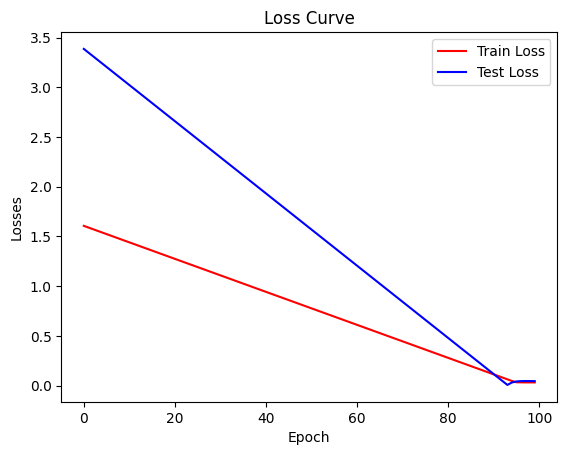

In [16]:
## Loss Curve Plot

plt.plot(epoch_loop, losses, label="Train Loss", color="red")
plt.plot(epoch_loop, test_losses, label="Test Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Losses")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [17]:
model.state_dict()

OrderedDict([('weights', tensor([0.7132])), ('bias', tensor([0.2261]))])

In [18]:
weight, bias

(0.7, 0.3)

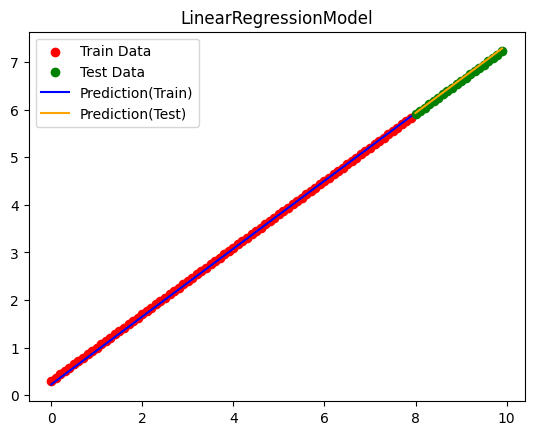

In [19]:
with torch.inference_mode():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

plt.title("LinearRegressionModel")
plt.scatter(X_train, y_train, label="Train Data", color="red")
plt.scatter(X_test, y_test, label="Test Data", color="green")
plt.plot(X_train, y_pred_train, label="Prediction(Train)", color="Blue")
plt.plot(X_test, y_pred_test, label="Prediction(Test)", color="orange")
plt.legend()
plt.show()

In [20]:
import pathlib

MODEL_DIR_PATH = pathlib.Path("models")
MODEL_DIR_PATH.mkdir(exist_ok=True)

MODEL_ABSOLUTE_PATH = MODEL_DIR_PATH / "linear_regression_model.pth"

# Torch Model saving

torch.save(model.state_dict(), MODEL_ABSOLUTE_PATH)